<a href="https://colab.research.google.com/github/Abraheem2010/image-processing-from-scratch/blob/main/Assignment-1-Histogram-Equalization/solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/dnevo/ImageProcessing/blob/main/ImageProcessingEx_01_HistogramEqualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Processing Assignment 1: Histogram Equalization

Before we start, please put your names and IDs in following format

: Firstname LASTNAME, #00000000   //   (e.g.) Dana LEVI, #12345678

**Your Answer:**   
Xxxxx XXXXX, #nnnnnn

# Histogram Equalization

In this exercise you will implement the **Histogram Equalization** algorithm.

**Pay Attention!** Do not use image processing functions such (ex. `numpy.histogram()`). You have to implement it by yourself.

Method: as explained in class.

Notes:
*   Write your code in the dedicated areas (TODO blocks). You can add helper functions.
*   Submission email should include a link to Colab submission notebook located on your Google Drive with Commenter access right to nev1958a@gmail.com
*   The solution notebook should be able to be run (‘Run all’) with no errors.
In case of errors, the submission will be disqualified.
*   Grade will depend on correct performance on several grayscale images and on clean programming and documentation.
*   Do not forget to add the Names and Student I.D. at the top of the notebook.




# Getting Started

## Setup Code
Before getting started, we need to run some boilerplate code to set up our environment. You will need to rerun this setup code each time you start the notebook.

In [30]:
import urllib.request
from io import BytesIO
import numpy as np
import matplotlib.pyplot as plt
import PIL

In [31]:
GITHUB_PATH = 'https://raw.githubusercontent.com/dnevo/ImageProcessing/main/images/'

In [32]:
def read_file(file_name:str, file_path:str=GITHUB_PATH) -> np.ndarray:
    '''
    Accept an image file name (defaulty located in GitHub) and return the image 
    in a numpy array.

    Args:
        file_name: the file name
        file_path: the file path.. Default value is Doron's Github repo.

    Returns:
        the image converted into a Numpy array.
    '''
    file_url = file_path.rstrip('/') + '/' + file_name
    with urllib.request.urlopen(file_url, timeout=30) as response:
        fp = BytesIO(response.read())

    img_pil = PIL.Image.open(fp)
    return np.array(img_pil, dtype='int16')

In [33]:
img = read_file(file_name='house.tiff')

In [34]:
def plot_img(img: np.array, figsize:(int,int)=None):
    if figsize:
        plt.figure(figsize = figsize)
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)

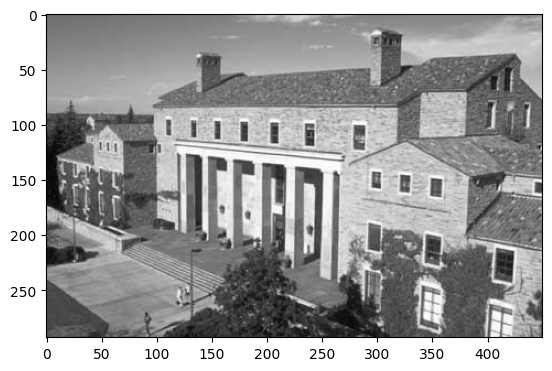

In [35]:
plot_img(img)

In [ ]:
def hist_shape(img_src: np.array, img_dest: np.array) -> np.array:
    '''
    This function perform an grayscale image enhancement using Histogram 
    Equalization.
    Args:
        img_src: image in int16 format - the image to enhance
        img_dest: image in int16 format - the histogram will be based on it.

    Returns:
        img_new: Returned image, in int16 format - the enhanced image
    '''

    ######################################################################
    # TODO: Implement image enhancement using histogram Equalization.
    ######################################################################

    # Algorithm: histogram matching. Remap img_src's gray levels so its
    # cumulative histogram (CDF) follows img_dest's CDF, giving img_src the
    # tonal distribution of img_dest.

    # Step 1: Validate that both inputs are 2D numpy arrays, then clip to [0, 255]
    if not isinstance(img_src, np.ndarray) or img_src.ndim != 2:
        raise ValueError('img_src must be a 2D numpy array.')
    if not isinstance(img_dest, np.ndarray) or img_dest.ndim != 2:
        raise ValueError('img_dest must be a 2D numpy array.')
    img_src = np.clip(img_src.astype(np.int16), 0, 255)
    img_dest = np.clip(img_dest.astype(np.int16), 0, 255)

    # Step 2: Compute 256-bin histogram for source image (manually, without numpy.histogram)
    src_hist = np.zeros(256, dtype=np.int64)
    for pixel in img_src.ravel():
        src_hist[int(pixel)] += 1

    # Step 3: Compute 256-bin histogram for destination image
    dest_hist = np.zeros(256, dtype=np.int64)
    for pixel in img_dest.ravel():
        dest_hist[int(pixel)] += 1

    # Step 4: Compute normalized CDF for source histogram
    src_cdf = np.zeros(256, dtype=np.float64)
    running_sum = 0
    total_src = int(src_hist.sum())
    for i in range(256):
        running_sum += int(src_hist[i])
        src_cdf[i] = running_sum / total_src  # Normalize to [0, 1]

    # Step 5: Compute normalized CDF for destination histogram
    dest_cdf = np.zeros(256, dtype=np.float64)
    running_sum = 0
    total_dest = int(dest_hist.sum())
    for i in range(256):
        running_sum += int(dest_hist[i])
        dest_cdf[i] = running_sum / total_dest  # Normalize to [0, 1]

    # Step 6: Build a lookup table (LUT) by matching source CDF to destination CDF
    lut = np.zeros(256, dtype=np.uint8)
    dest_level = 0
    for src_level in range(256):
        # Advance dest_level until dest_cdf >= src_cdf for the current source level
        while dest_level < 255 and dest_cdf[dest_level] < src_cdf[src_level]:
            dest_level += 1
        # Pick the destination level whose CDF value is closest to the source CDF
        if dest_level > 0:
            prev_gap = abs(dest_cdf[dest_level - 1] - src_cdf[src_level])
            curr_gap = abs(dest_cdf[dest_level] - src_cdf[src_level])
            if prev_gap <= curr_gap:
                lut[src_level] = dest_level - 1
                continue
        lut[src_level] = dest_level

    # Step 7: Apply the LUT to remap all source pixel values to the new gray levels
    img_new = lut[img_src].astype(np.int16)

    ######################################################################
    #                            END OF YOUR CODE                        #
    ######################################################################

    return img_new

In [ ]:
def create_tiled_image(img_big: np.array, img_small: np.array) -> np.array:
    '''
    This function receives 2 grayscale image (matrix of int16, values:0..255) and 
    creates a new image. The new image consists of tiles of the small image 
    which forms the big image. Each of the small image tiles is processed using 
    the histShape function to match the histogram of the big image in the same 
    location.
    Args:
        img_big: image in int16 format - the image to enhance
        img_small: image in int16 format - the histogram will be based on it.

    Returns:
        img_new: returned image, in int16 format - the tiled image
    '''

    ######################################################################
    # TODO: Implement tiles image using histogram Equalization.
    ######################################################################

    # Algorithm: rebuild img_big from tiles the size of img_small. Each tile is
    # img_small histogram-matched (via hist_shape) to the underlying block of
    # img_big, so every tile blends with its local region.

    # Step 1: Validate that both inputs are 2D numpy arrays, then clip to [0, 255]
    if not isinstance(img_big, np.ndarray) or img_big.ndim != 2:
        raise ValueError('img_big must be a 2D numpy array.')
    if not isinstance(img_small, np.ndarray) or img_small.ndim != 2:
        raise ValueError('img_small must be a 2D numpy array.')
    img_big = np.clip(img_big.astype(np.int16), 0, 255)
    img_small = np.clip(img_small.astype(np.int16), 0, 255)

    # Step 2: Get dimensions of the big image and the tile (small image)
    big_height, big_width = img_big.shape
    tile_height, tile_width = img_small.shape

    # Step 3: Allocate the output image with the same size as the big image
    img_new = np.empty((big_height, big_width), dtype=np.int16)

    # Step 4: Iterate over the big image in tile-sized blocks
    for row in range(0, big_height, tile_height):
        row_end = min(row + tile_height, big_height)
        src_row_end = row_end - row  # Handle partial tiles at the bottom edge

        for col in range(0, big_width, tile_width):
            col_end = min(col + tile_width, big_width)
            src_col_end = col_end - col  # Handle partial tiles at the right edge

            # Extract the corresponding region from the big image (destination histogram)
            img_dest_tile = img_big[row:row_end, col:col_end]

            # Crop the small image to match the tile size (handles edge cases)
            img_src_tile = img_small[:src_row_end, :src_col_end]

            # Apply histogram matching and place the result in the output image
            img_new[row:row_end, col:col_end] = hist_shape(img_src_tile, img_dest_tile)

    ######################################################################
    #                            END OF YOUR CODE                        #
    ######################################################################

    return img_new

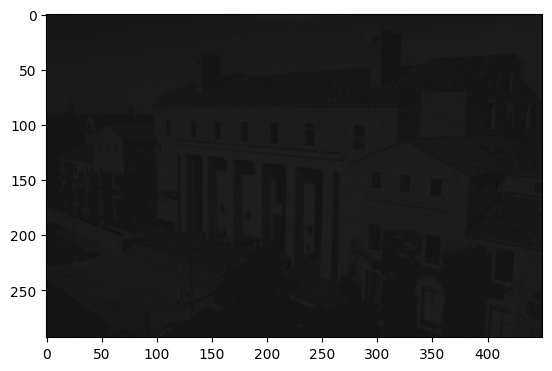

In [38]:
img_src = read_file(file_name='darkimage.tiff')
plot_img(img_src)

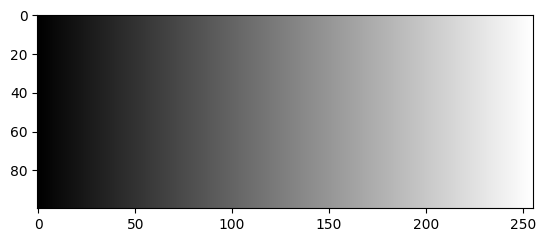

In [39]:
img_dest = read_file(file_name='flatHistShape.tiff')
plot_img(img_dest)

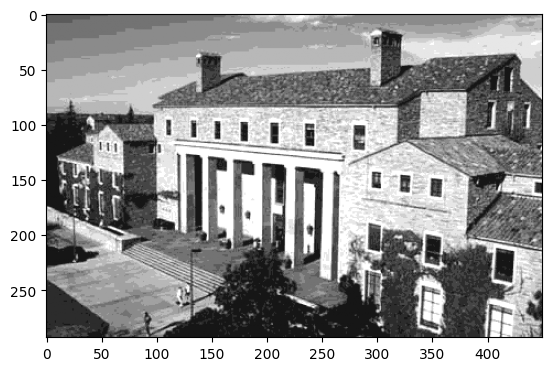

In [40]:
img_new = hist_shape(img_src, img_dest)
plot_img(img_new)

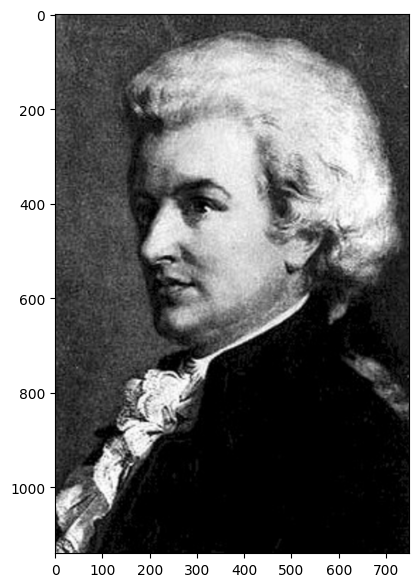

In [41]:
img_big = read_file(file_name='bigMozart.tiff')
plot_img(img_big, figsize=(7,7))

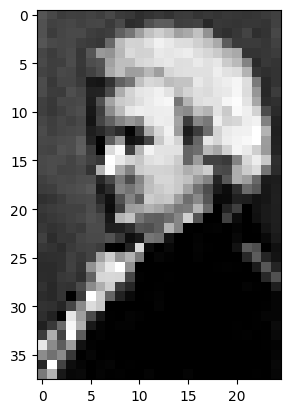

In [42]:
img_small = read_file(file_name='smallMozart.tiff')
plot_img(img_small)

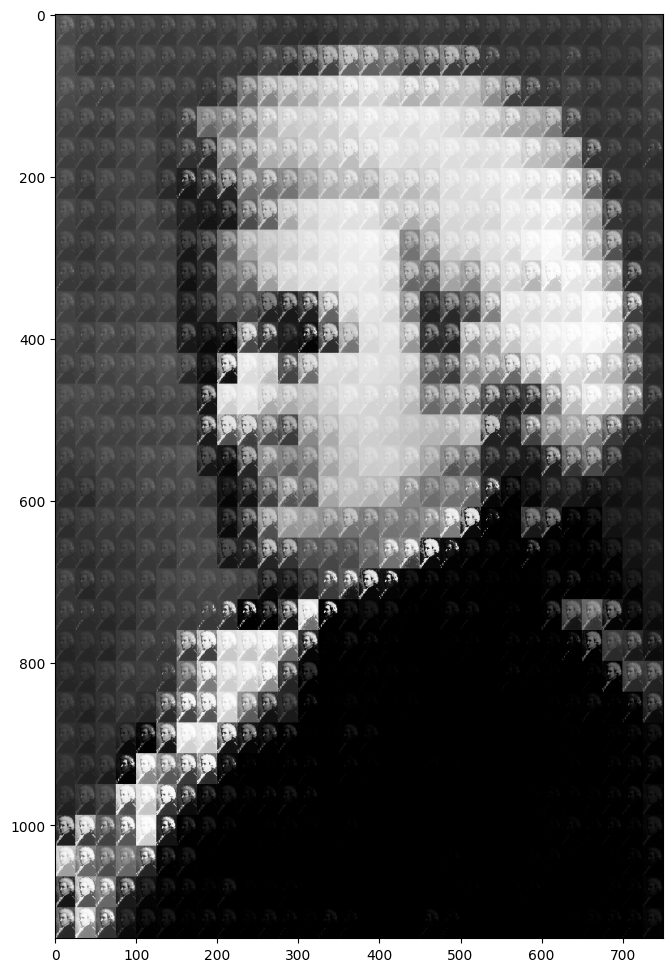

In [43]:
img_new = create_tiled_image(img_big, img_small)
plot_img(img_new, figsize=(12,12))